In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
z = np.load("traces.npz")
traces = z["traces"].astype(np.float64)
plaintexts = z["plaintexts"].astype(np.uint8)
print("Trace shape      :", traces.shape)
print("Trace dtype      :", traces.dtype)
print("Plaintext shape  :", plaintexts.shape)
print("Plaintext dtype  :", plaintexts.dtype)
assert traces.shape == (2000, 800)
assert plaintexts.shape == (2000, 16)
N_TRACES = traces.shape[0]
N_SAMPLES = traces.shape[1]

Trace shape      : (2000, 800)
Trace dtype      : float64
Plaintext shape  : (2000, 16)
Plaintext dtype  : uint8


In [4]:
SBOX = np.array([
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16
], dtype=np.uint8)

HW = np.array([bin(x).count("1") for x in range(256)], dtype=np.uint8)

In [5]:
import numpy as np

# AES-128 S-box
SBOX = np.array([
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16
], dtype=np.uint8)

# Hamming-weight lookup table
HW = np.array(
    [bin(x).count("1") for x in range(256)],
    dtype=np.uint8
)

# Sanity checks
print("SBOX length:", len(SBOX))
print("HW length:", len(HW))
print("SBOX[0x00] =", hex(int(SBOX[0x00])))
print("HW[0x00] =", int(HW[0x00]))
print("HW[0xff] =", int(HW[0xff]))

SBOX length: 256
HW length: 256
SBOX[0x00] = 0x63
HW[0x00] = 0
HW[0xff] = 8


In [6]:
byte_index = 0
key_guess = 0x00

intermediate = SBOX[plaintexts[:, byte_index] ^ key_guess]
prediction = HW[intermediate]

print(intermediate.shape)
print(prediction.shape)
print(prediction[:10])

(2000,)
(2000,)
[3 5 5 4 5 5 4 5 3 4]


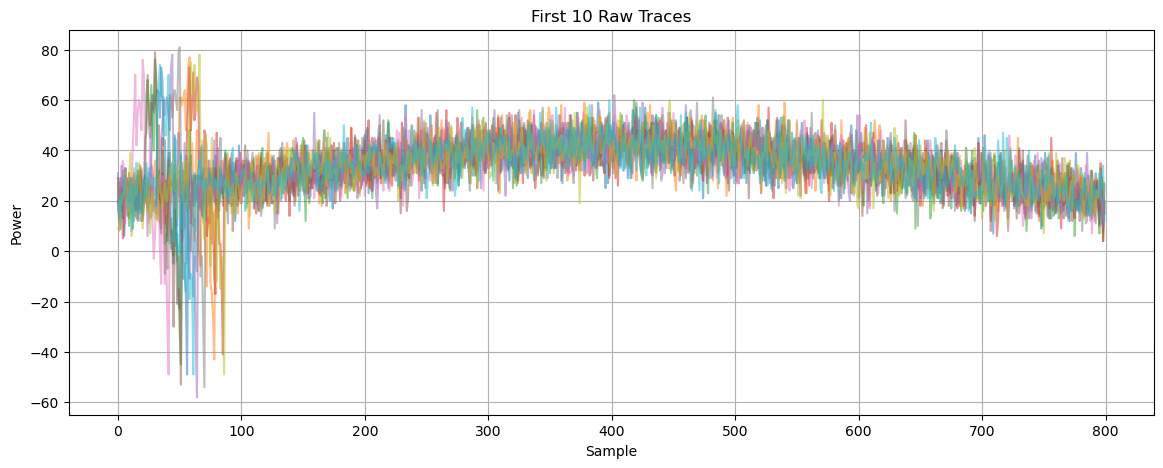

In [7]:
plt.figure(figsize=(14, 5))

for i in range(10):
    plt.plot(traces[i], alpha=0.5)

plt.xlabel("Sample")
plt.ylabel("Power")
plt.title("First 10 Raw Traces")
plt.grid()
plt.show()

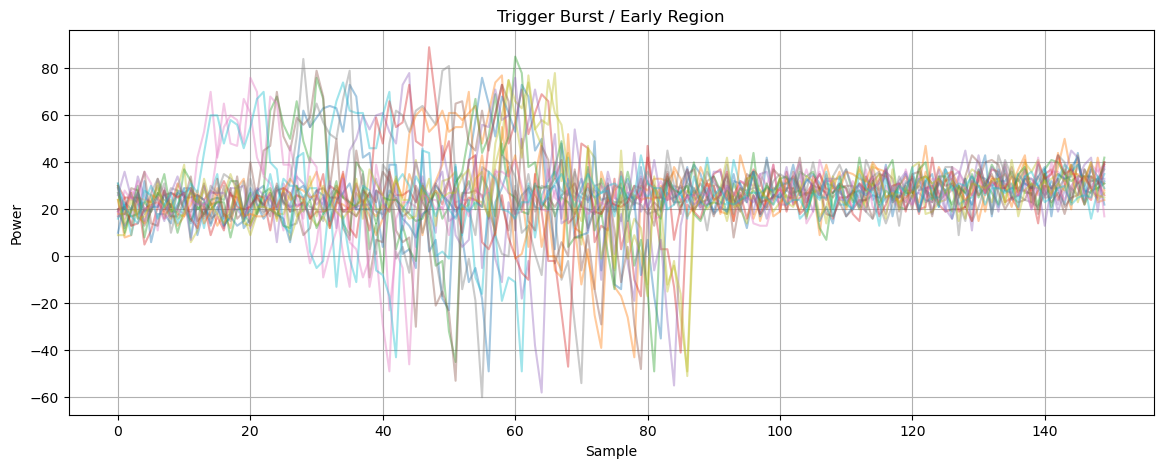

In [8]:
plt.figure(figsize=(14, 5))

for i in range(20):
    plt.plot(traces[i, :150], alpha=0.4)

plt.xlabel("Sample")
plt.ylabel("Power")
plt.title("Trigger Burst / Early Region")
plt.grid()
plt.show()

In [9]:
baseline = traces[:, :15].mean(axis=1, keepdims=True)

early = traces[:, :120] - baseline

# Rolling energy detects the strong burst even though it
# occurs at a different location in different traces.

WINDOW = 15

burst_energy = np.array([
    np.convolve(
        trace ** 2,
        np.ones(WINDOW) / WINDOW,
        mode="same"
    )
    for trace in early
])

burst_positions = np.argmax(burst_energy, axis=1)

target_position = int(np.median(burst_positions))

print("Burst position range:",
      burst_positions.min(),
      "to",
      burst_positions.max())

print("Target burst position:", target_position)

Burst position range: 20 to 82
Target burst position: 43


In [11]:
def find_shift(trace, reference, search_range=(-60, 60)):
    best_corr = -np.inf
    best_shift = 0

    for shift in range(search_range[0], search_range[1] + 1):

        if shift >= 0:
            a = trace[shift:150]
            b = reference[:150-shift]
        else:
            a = trace[:150+shift]
            b = reference[-shift:150]

        c = normalized_corr(a, b)

        if c > best_corr:
            best_corr = c
            best_shift = shift

    return best_shift, best_corr

In [12]:
def shift_trace(trace, shift):
    """
    Shift the trace by an integer number of samples.

    Positive shift:
        moves signal to the right.

    Negative shift:
        moves signal to the left.
    """

    out = np.zeros_like(trace)

    if shift > 0:
        out[shift:] = trace[:-shift]

    elif shift < 0:
        out[:shift] = trace[-shift:]

    else:
        out[:] = trace

    return out

In [14]:
rough_shifts = target_position - burst_positions

rough_aligned = np.array([
    shift_trace(trace, shift)
    for trace, shift in zip(traces, rough_shifts)
])

In [15]:
def normalized_corr(a, b):
    """
    Pearson-like normalized correlation between two vectors.
    """

    a = a - np.mean(a)
    b = b - np.mean(b)

    denominator = np.sqrt(
        np.sum(a * a) *
        np.sum(b * b)
    )

    if denominator == 0:
        return 0.0

    return np.sum(a * b) / denominator


# Build a template after rough alignment.
reference = np.median(
    rough_aligned[:, :150],
    axis=0
)


def find_fine_shift(trace, reference, search_range=(-12, 12)):
    """
    Find the small remaining shift by maximizing
    correlation against the trigger template.
    """

    best_corr = -np.inf
    best_shift = 0

    for shift in range(
        search_range[0],
        search_range[1] + 1
    ):

        if shift >= 0:
            a = trace[shift:150]
            b = reference[:150-shift]

        else:
            a = trace[:150+shift]
            b = reference[-shift:150]

        corr_value = normalized_corr(a, b)

        if corr_value > best_corr:
            best_corr = corr_value
            best_shift = shift

    return best_shift, best_corr


fine_shifts = []
fine_correlations = []

for trace in rough_aligned:

    shift, correlation = find_fine_shift(
        trace,
        reference
    )

    fine_shifts.append(shift)
    fine_correlations.append(correlation)


fine_shifts = np.array(fine_shifts)
fine_correlations = np.array(fine_correlations)


# Apply fine correction.
aligned = np.array([
    shift_trace(trace, -shift)
    for trace, shift in zip(
        rough_aligned,
        fine_shifts
    )
])


print(
    "Fine-shift range:",
    fine_shifts.min(),
    "to",
    fine_shifts.max()
)

print(
    "Median fine alignment correlation:",
    np.median(fine_correlations)
)

Fine-shift range: -12 to 5
Median fine alignment correlation: 0.8931639260478121


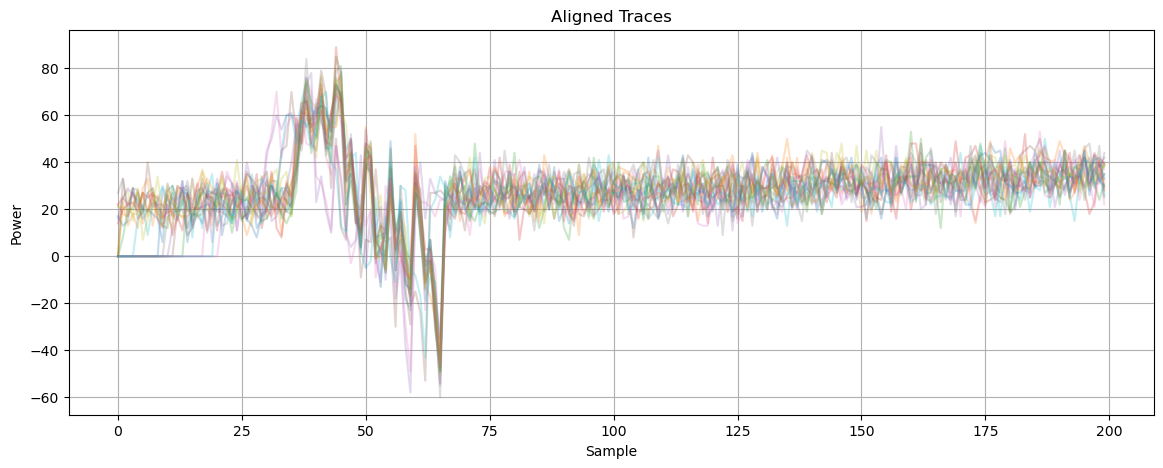

In [16]:
plt.figure(figsize=(14, 5))

for i in range(20):
    plt.plot(
        aligned[i, :200],
        alpha=0.25
    )

plt.xlabel("Sample")
plt.ylabel("Power")
plt.title("Aligned Traces")
plt.grid()
plt.show()

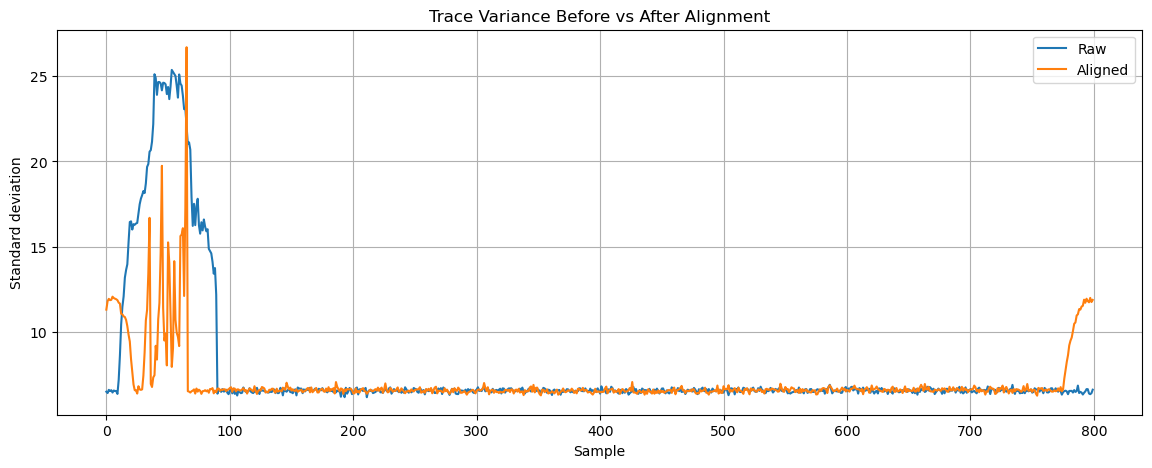

In [17]:
plt.figure(figsize=(14, 5))

plt.plot(
    traces.std(axis=0),
    label="Raw"
)

plt.plot(
    aligned.std(axis=0),
    label="Aligned"
)

plt.xlabel("Sample")
plt.ylabel("Standard deviation")
plt.title("Trace Variance Before vs After Alignment")
plt.legend()
plt.grid()
plt.show()

In [18]:
ANALYSIS_START = 100
ANALYSIS_END = 800

T = aligned[
    :,
    ANALYSIS_START:ANALYSIS_END
].copy()

# Center each sample.
T -= T.mean(
    axis=0,
    keepdims=True
)

print("CPA matrix:", T.shape)

CPA matrix: (2000, 700)


In [20]:
def cpa_byte(
    byte_index,
    plaintexts,
    measured_traces
):
    """
    Perform first-round AES CPA for one plaintext byte.

    Leakage model:

        HW(SBOX[plaintext_byte XOR key_guess])
    """

    n_traces = plaintexts.shape[0]

    # --------------------------------------------------------
    # Build 256 hypothetical leakage vectors
    # --------------------------------------------------------

    hypotheses = np.empty(
        (256, n_traces),
        dtype=np.float64
    )

    for key_guess in range(256):

        sbox_output = SBOX[
            plaintexts[:, byte_index] ^ key_guess
        ]

        hypotheses[key_guess] = HW[
            sbox_output
        ]

    # Center hypotheses.
    H = hypotheses - hypotheses.mean(
        axis=1,
        keepdims=True
    )

    # --------------------------------------------------------
    # Pearson correlation
    # --------------------------------------------------------

    numerator = H @ measured_traces

    H_norm = np.sqrt(
        np.sum(
            H ** 2,
            axis=1,
            keepdims=True
        )
    )

    T_norm = np.sqrt(
        np.sum(
            measured_traces ** 2,
            axis=0,
            keepdims=True
        )
    )

    corr = numerator / (
        H_norm @ T_norm
    )

    # Maximum absolute correlation for every key guess.
    score = np.max(
        np.abs(corr),
        axis=1
    )

    ranking = np.argsort(score)[::-1]

    best_key = int(ranking[0])
    second_key = int(ranking[1])

    best_score = float(score[best_key])
    second_score = float(score[second_key])

    peak_sample_local = int(
        np.argmax(
            np.abs(
                corr[best_key]
            )
        )
    )

    peak_sample = (
        ANALYSIS_START +
        peak_sample_local
    )

    margin = (
        best_score -
        second_score
    )

    return {
        "corr": corr,
        "score": score,
        "ranking": ranking,
        "best_key": best_key,
        "second_key": second_key,
        "best_score": best_score,
        "second_score": second_score,
        "margin": margin,
        "peak_sample": peak_sample
    }


In [21]:
byte0_result = cpa_byte(
    byte_index=0,
    plaintexts=plaintexts,
    measured_traces=T
)

print(
    "Byte 0 best candidate:",
    f"{byte0_result['best_key']:02x}"
)

print(
    "Correlation:",
    f"{byte0_result['best_score']:.6f}"
)

print(
    "Second candidate:",
    f"{byte0_result['second_key']:02x}"
)

print(
    "Second correlation:",
    f"{byte0_result['second_score']:.6f}"
)

print(
    "Margin:",
    f"{byte0_result['margin']:.6f}"
)

print(
    "Peak sample:",
    byte0_result["peak_sample"]
)



Byte 0 best candidate: 8f
Correlation: 0.174722
Second candidate: 7a
Second correlation: 0.107279
Margin: 0.067443
Peak sample: 146


In [22]:
print("\nTop 10 candidates for byte 0:")

for rank, key_guess in enumerate(
    byte0_result["ranking"][:10],
    start=1
):

    print(
        f"{rank:2d}. "
        f"{key_guess:02x}   "
        f"{byte0_result['score'][key_guess]:.6f}"
    )


Top 10 candidates for byte 0:
 1. 8f   0.174722
 2. 7a   0.107279
 3. 8d   0.104507
 4. 65   0.104249
 5. 11   0.101478
 6. 26   0.100081
 7. 94   0.098755
 8. 14   0.098579
 9. 2f   0.097963
10. dd   0.094657


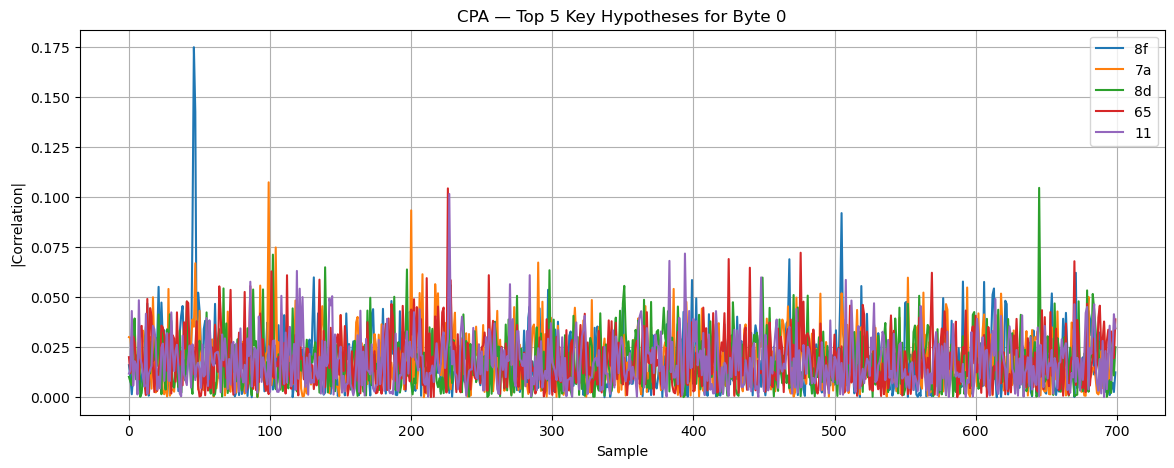

In [23]:
plt.figure(figsize=(14, 5))

for key_guess in byte0_result["ranking"][:5]:

    plt.plot(
        np.abs(
            byte0_result["corr"][key_guess]
        ),
        label=f"{key_guess:02x}"
    )

plt.xlabel("Sample")
plt.ylabel("|Correlation|")
plt.title("CPA — Top 5 Key Hypotheses for Byte 0")
plt.legend()
plt.grid()
plt.show()

In [24]:
results = []
best_keys = []

for byte_index in range(16):

    result = cpa_byte(
        byte_index=byte_index,
        plaintexts=plaintexts,
        measured_traces=T
    )

    results.append(result)

    best_keys.append(
        result["best_key"]
    )

    print(
        f"Byte {byte_index:02d} | "
        f"best = {result['best_key']:02x} | "
        f"corr = {result['best_score']:.6f} | "
        f"second = {result['second_key']:02x} | "
        f"margin = {result['margin']:.6f} | "
        f"peak = {result['peak_sample']}"
    )

Byte 00 | best = 8f | corr = 0.174722 | second = 7a | margin = 0.067443 | peak = 146
Byte 01 | best = 3c | corr = 0.145494 | second = 76 | margin = 0.040800 | peak = 186
Byte 02 | best = 1d | corr = 0.159656 | second = 42 | margin = 0.060795 | peak = 226
Byte 03 | best = 7a | corr = 0.150703 | second = 5b | margin = 0.046396 | peak = 266
Byte 04 | best = 46 | corr = 0.186853 | second = 9a | margin = 0.092830 | peak = 306
Byte 05 | best = b2 | corr = 0.186831 | second = c3 | margin = 0.085221 | peak = 346
Byte 06 | best = e5 | corr = 0.171011 | second = df | margin = 0.068890 | peak = 386
Byte 07 | best = 90 | corr = 0.169554 | second = ca | margin = 0.061959 | peak = 426
Byte 08 | best = c4 | corr = 0.188926 | second = 05 | margin = 0.087514 | peak = 466
Byte 09 | best = a1 | corr = 0.169847 | second = d5 | margin = 0.068240 | peak = 506
Byte 10 | best = 7f | corr = 0.191493 | second = 54 | margin = 0.086744 | peak = 546
Byte 11 | best = 28 | corr = 0.210975 | second = 17 | margin = 0.

In [ ]:
ranking[0]

In [25]:
candidate_key = "".join(
    f"{key:02x}"
    for key in best_keys
)

print("\n========================================")
print("Candidate AES-128 key:")
print(candidate_key)
print("========================================")


# Flag-format version
print(
    f"Intern_Pro_Max{{{candidate_key}}}"
)


Candidate AES-128 key:
8f3c1d7a46b2e590c4a17f28d63b0e95
Intern_Pro_Max{8f3c1d7a46b2e590c4a17f28d63b0e95}


In [26]:
print("\nByte-by-byte confidence:\n")

print(
    "Byte | Best | Corr       | "
    "2nd  | Corr       | Margin     | Peak"
)

print("-" * 75)

for i, result in enumerate(results):

    print(
        f"{i:4d} | "
        f"{result['best_key']:02x}   | "
        f"{result['best_score']:.6f} | "
        f"{result['second_key']:02x}   | "
        f"{result['second_score']:.6f} | "
        f"{result['margin']:.6f} | "
        f"{result['peak_sample']:4d}"
    )


Byte-by-byte confidence:

Byte | Best | Corr       | 2nd  | Corr       | Margin     | Peak
---------------------------------------------------------------------------
   0 | 8f   | 0.174722 | 7a   | 0.107279 | 0.067443 |  146
   1 | 3c   | 0.145494 | 76   | 0.104694 | 0.040800 |  186
   2 | 1d   | 0.159656 | 42   | 0.098861 | 0.060795 |  226
   3 | 7a   | 0.150703 | 5b   | 0.104307 | 0.046396 |  266
   4 | 46   | 0.186853 | 9a   | 0.094023 | 0.092830 |  306
   5 | b2   | 0.186831 | c3   | 0.101609 | 0.085221 |  346
   6 | e5   | 0.171011 | df   | 0.102121 | 0.068890 |  386
   7 | 90   | 0.169554 | ca   | 0.107594 | 0.061959 |  426
   8 | c4   | 0.188926 | 05   | 0.101411 | 0.087514 |  466
   9 | a1   | 0.169847 | d5   | 0.101607 | 0.068240 |  506
  10 | 7f   | 0.191493 | 54   | 0.104749 | 0.086744 |  546
  11 | 28   | 0.210975 | 17   | 0.121171 | 0.089804 |  586
  12 | d6   | 0.187211 | 24   | 0.106510 | 0.080700 |  626
  13 | 3b   | 0.188400 | 73   | 0.108603 | 0.079797 |  666
  14 |

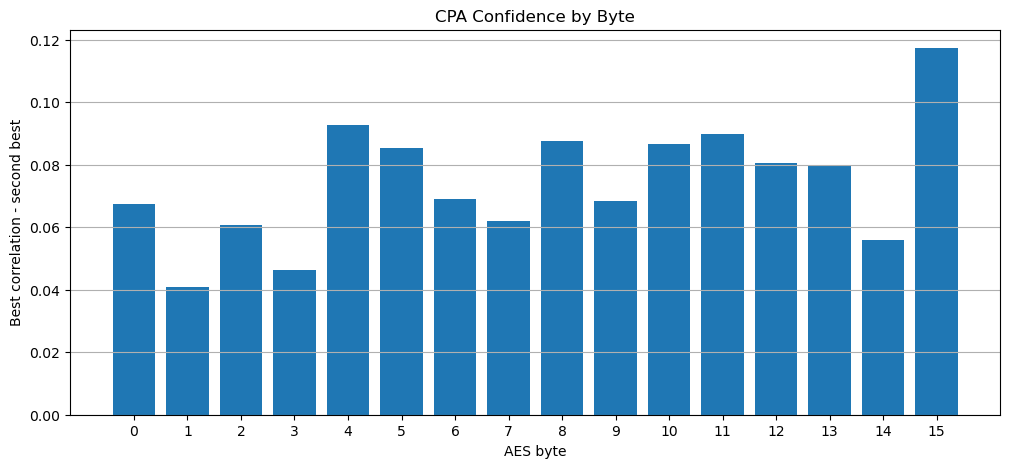

In [27]:
margins = np.array([
    result["margin"]
    for result in results
])

plt.figure(figsize=(12, 5))

plt.bar(
    np.arange(16),
    margins
)

plt.xlabel("AES byte")
plt.ylabel("Best correlation - second best")
plt.title("CPA Confidence by Byte")
plt.xticks(np.arange(16))
plt.grid(axis="y")
plt.show()

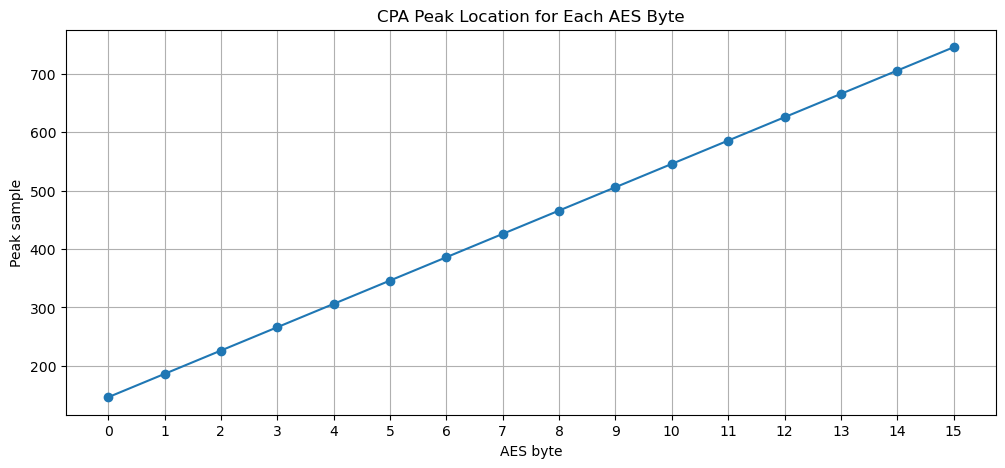

In [28]:
peak_samples = np.array([
    result["peak_sample"]
    for result in results
])

plt.figure(figsize=(12, 5))

plt.plot(
    np.arange(16),
    peak_samples,
    marker="o"
)

plt.xlabel("AES byte")
plt.ylabel("Peak sample")
plt.title("CPA Peak Location for Each AES Byte")
plt.xticks(np.arange(16))
plt.grid()
plt.show()


In [29]:
print("\nTrace-count convergence for Byte 0:")

for n in [250, 500, 1000, 1500, 2000]:

    subset_T = aligned[
        :n,
        ANALYSIS_START:ANALYSIS_END
    ].copy()

    subset_T -= subset_T.mean(
        axis=0,
        keepdims=True
    )

    subset_plaintexts = plaintexts[:n]

    result = cpa_byte(
        byte_index=0,
        plaintexts=subset_plaintexts,
        measured_traces=subset_T
    )

    print(
        f"{n:4d} traces -> "
        f"{result['best_key']:02x} "
        f"(corr={result['best_score']:.6f})"
    )


Trace-count convergence for Byte 0:
 250 traces -> 68 (corr=0.295581)
 500 traces -> 59 (corr=0.199871)
1000 traces -> 8f (corr=0.180610)
1500 traces -> 8f (corr=0.184695)
2000 traces -> 8f (corr=0.174722)


In [30]:
print("\nFINAL SUMMARY")
print("-------------")

print("Candidate key :", candidate_key)
print(
    "Flag format   :",
    f"Intern_Pro_Max{{{candidate_key}}}"
)

print("\nPeak samples:")
print(peak_samples)

print("\nMargins:")
print(margins)


FINAL SUMMARY
-------------
Candidate key : 8f3c1d7a46b2e590c4a17f28d63b0e95
Flag format   : Intern_Pro_Max{8f3c1d7a46b2e590c4a17f28d63b0e95}

Peak samples:
[146 186 226 266 306 346 386 426 466 506 546 586 626 666 706 746]

Margins:
[0.06744325 0.04079995 0.06079545 0.04639589 0.09283035 0.08522145
 0.06889015 0.0619592  0.08751404 0.06824015 0.08674437 0.08980442
 0.08070037 0.07979688 0.05583655 0.11733309]
